In [155]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library(CCA)
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(corrplot)
library(ggrepel)


theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [139]:
tpm<- read.table('../data/7_mature_rna_tss_tpm_norm_by_deseq2.tsv', header=T, sep="\t", row.names=1, check.names = FALSE)
colnames(tpm) = paste0(rep(c("WT", "MUT"), each = 3), c("_rep1", "_rep2", "_rep3")) 

In [5]:
df<- read.table("../data/11_isoform_and_chromatin_state_usage_combined.tsv", header = T, row.names = 1, sep = "\t", check.names = F)

In [7]:
dominance_threshold = 0.3
mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- c("low", "medium", "high")

In [9]:
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')

## Low expression genes

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


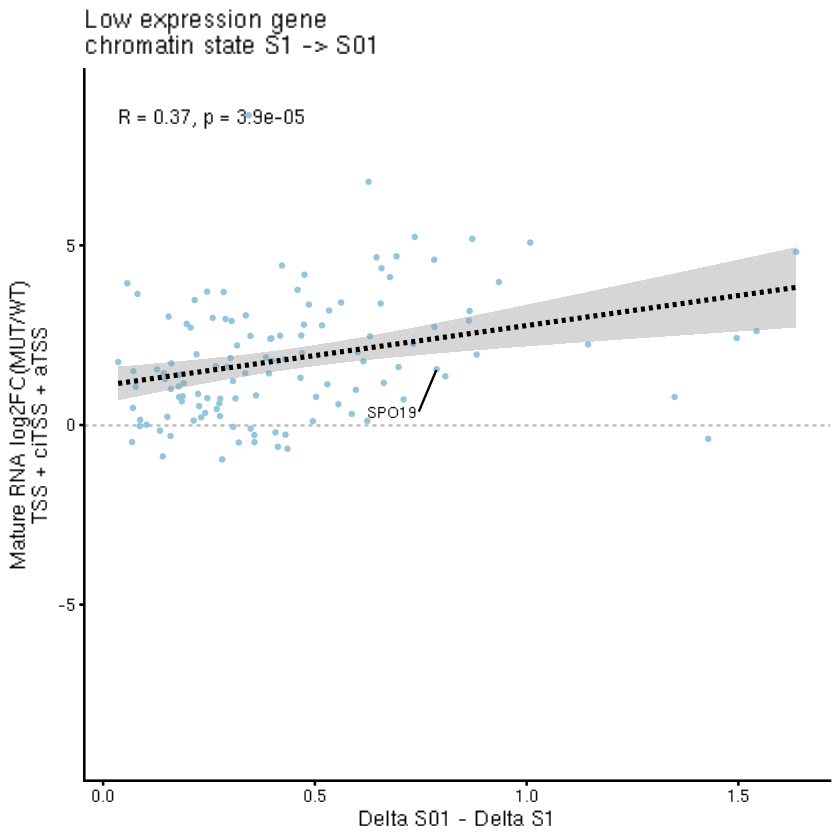

In [156]:
down_state = c('fully-nucleosomal')
up_state = c('promoter-accessible')

candidates <- df %>%
    filter(
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_tss +lfc_citss + lfc_atss , 
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'low')

label_gene<- candidates["SPO19",]

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
    geom_point(aes(color = class), size = 0.7) +
    labs(x = 'Delta S01 - Delta S1',  y = 'Mature RNA log2FC(MUT/WT)\nTSS + ciTSS + aTSS', 
         title = 'Low expression gene\nchromatin state S1 -> S01') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel( data = label_gene, aes(label = geneid), size = 3, box.padding = 1.5, max.overlaps = 3) +
    theme(legend.position = "none")  +
    ylim(-9, 9)

ggsave('../figures/Figure3_correlation_chromain_isoform_low_expr.pdf', width = 4, height = 3)

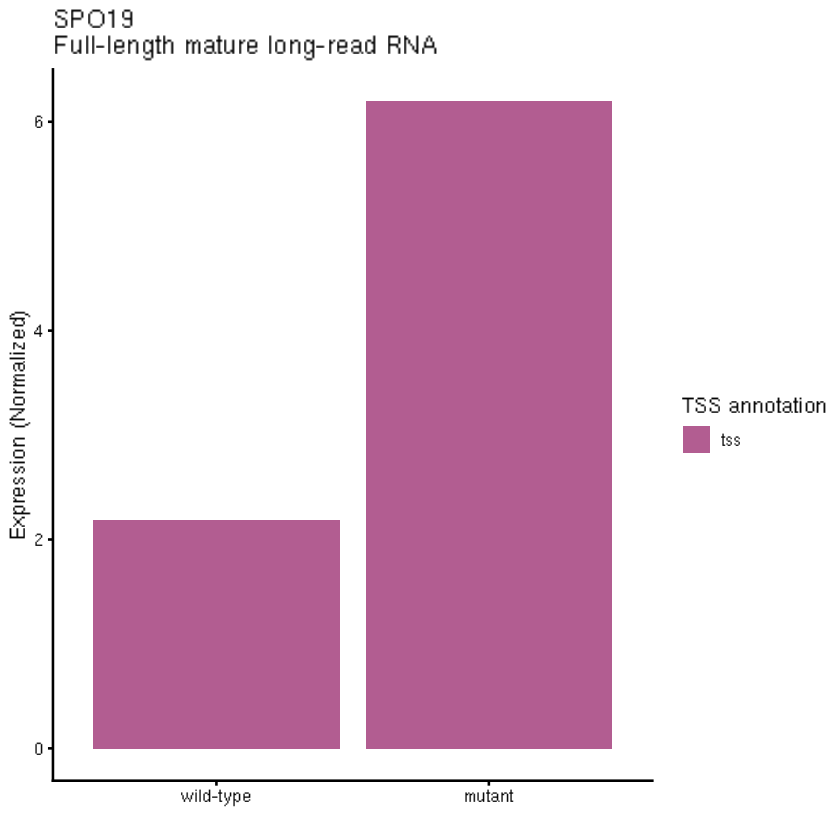

In [161]:
plot_expr_telo(tpm, "SPO19")
ggsave('../figures/Figure3_SPO19_cpm.pdf', width = 5, height = 3)

## medium expression genes

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


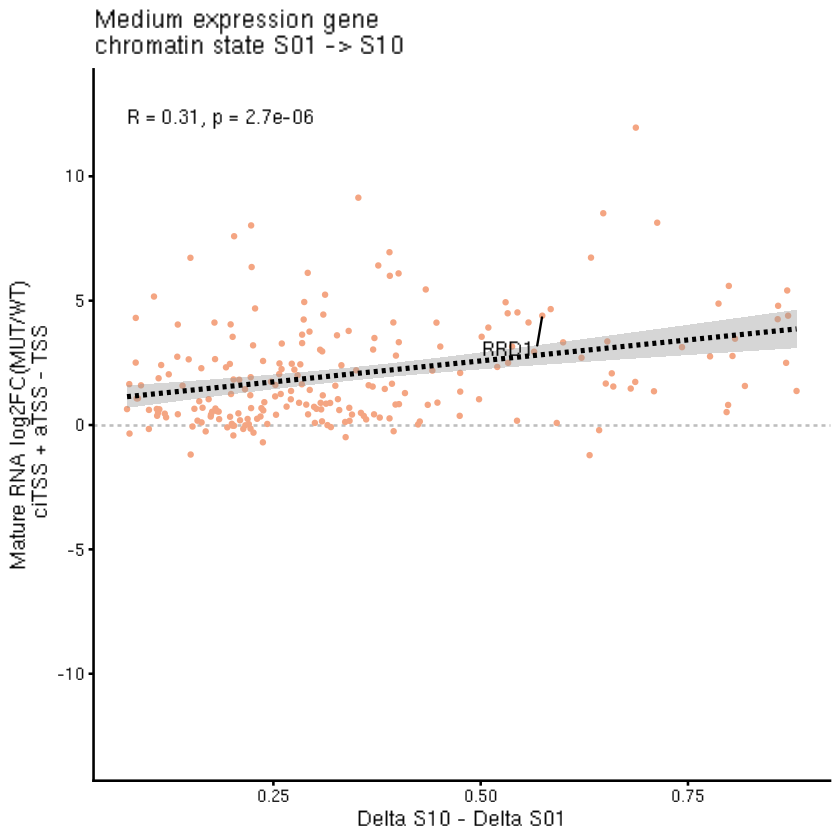

In [141]:
down_state = c('promoter-accessible')
up_state = c('intragenic-accessible')

candidates <- df %>%
    filter(
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_citss + lfc_atss - lfc_tss,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold)  %>% filter(class == 'medium')

label_gene<- candidates["RRD", ]

candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
    geom_point(aes(color = class), size = 0.7) +
    labs(x = 'Delta S10 - Delta S01',  y = 'Mature RNA log2FC(MUT/WT)\n ciTSS + aTSS - TSS', 
         title = 'Medium expression gene\nchromatin state S01 -> S10') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman",
             label.x.npc = "left", label.y.npc = "top", size = 4) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = label_gene,
        aes(label = geneid), size = 4, box.padding = 1) +
    theme(legend.position = "none") +
    ylim(-13, 13)

ggsave('../figures/Figure3_correlation_chromain_isoform_medium_expr.pdf', width = 4, height = 3)

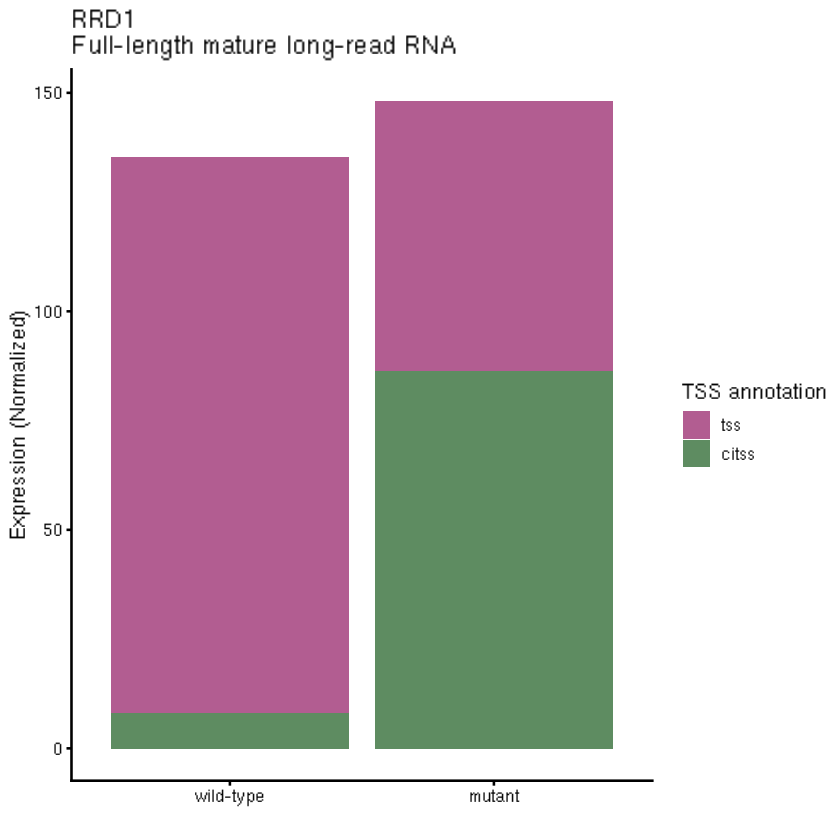

In [162]:
plot_expr_telo(tpm, "RRD1")
ggsave('../figures/Figure3_RRD1_cpm.pdf', width = 5, height = 3)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


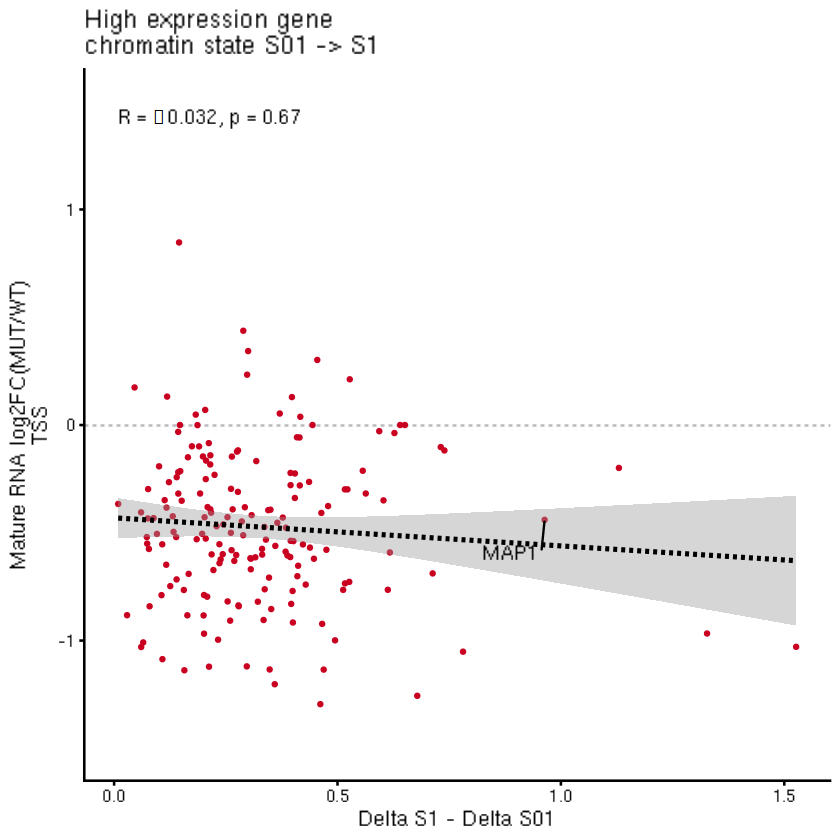

In [154]:
down_state = c('promoter-accessible')
up_state = c('fully-nucleosomal')

candidates <- df %>%
    filter(
        if_any(all_of(down_state), ~ .x < 0),
        if_any(all_of(up_state),   ~ .x > 0)
    ) %>%
    mutate(
        shift_score = rowSums(across(all_of(up_state))) - rowSums(across(all_of(down_state))),
        shift_score_iso = lfc_tss,
        total_abs_change  = rowSums(across(all_of(chrom_level), abs)),
        target_abs_change = rowSums(across(all_of(c(down_state, up_state)), abs)),
        dominance = target_abs_change / total_abs_change,
        geneid = rownames(.)
    ) %>%
    arrange(desc(shift_score)) %>%
    filter(dominance >= dominance_threshold) %>% filter(class == 'high')

label_gene<- candidates["MAP1", ]


candidates %>% 
    ggplot(aes(x = shift_score, y = shift_score_iso)) +
    geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey') +
    geom_point(aes(color = class), size = 0.7) +
    labs(x = 'Delta S1 - Delta S01',  y = 'Mature RNA log2FC(MUT/WT)\nTSS', 
         title = 'High expression gene\nchromatin state S01 -> S1') +
    scale_color_manual(values = mcol) +
    stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
    geom_smooth(color = 'black', method = "glm", linetype = 'dashed') +
    geom_text_repel(
        data = label_gene,
        aes(label = geneid), size = 4, box.padding = 1) +
    theme(legend.position = "none") +
    ylim(-1.5, 1.5)

ggsave('../figures/Figure3_correlation_chromain_isoform_high_expr.pdf', width = 4, height = 3)

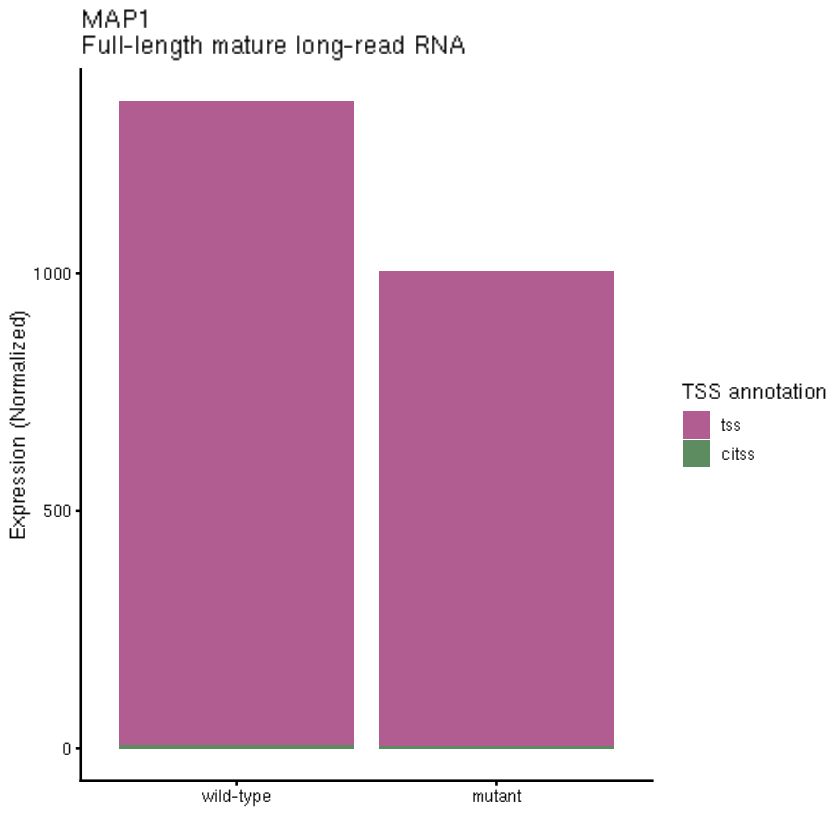

In [159]:
plot_expr_telo(tpm, "MAP1")
ggsave('../figures/Figure3_MAP1_cpm.pdf', width = 5, height = 3)

In [152]:
candidates["ZWF1", ]

,promoter-accessible,intragenic-accessible,co-accessible,fully-nucleosomal,fully-accessible,class,lfc_tss,lfc_citss,lfc_atss,WT_mean_co-accessible,⋯,WT_mean_tss,MUT_mean_atss,MUT_mean_citss,MUT_mean_tss,shift_score,shift_score_iso,total_abs_change,target_abs_change,dominance,geneid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
